In [284]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [285]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *
from defs.training_defs.loss import *
wavelengths = [str(w) for w in range(400, 2491, 10)]

In [286]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
train_loader, val_loader = get_dataloaders(spectra, fractions, batch_size=1)
# unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = train_loader.dataset[0][0].size(0)
print(train_loader.batch_size)
print(num_spectra)

Device: cpu
1
210


In [ ]:
convolution = ConvEncoder([train_loader.batch_size, 64, 64], [256, 256], c_d={'pad': 1}, num_spectra=num_spectra)

ratio = 1 # Coefficient of spectral angle mapper (SAM) loss
criterion = loss_mse_sam(ratio=ratio)

learning_rate = 1e-3
optimizer = optim.Adam(convolution.parameters(), lr=learning_rate)

n_epochs = 4

In [ ]:
train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    # Training loop
    convolution.train()
    tot_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion.calc(convolution(xb, yb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    train_losses.append(tot_loss / len(train_loader.dataset))

    convolution.eval()
    tot_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            tot_val += criterion.calc(convolution(xb, yb), xb).item() * xb.size(0)
    val_losses.append(tot_val / len(val_loader.dataset))

/Users/galacticmilk/Desktop/Michael's folder/[UNI]/[UTAT]/[science]/FINCH-Science_SyntheticData/defs/training_defs/loss.py:29: UserWarning: Using a target size (torch.Size([210])) that is different to the input size (torch.Size([1, 210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(x0_hat, x0)


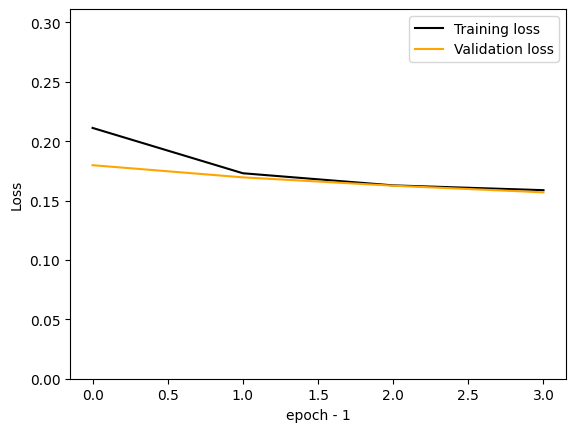

In [289]:
plt.plot(train_losses, color='black', label='Training loss')
plt.plot(val_losses, color='orange', label='Validation loss')
plt.ylim(0, max(max(train_losses), max(val_losses)) + 0.1)
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [290]:
print(f'Final training Loss: {train_losses[-1]:.5f}')
print(f'Final validation Loss: {val_losses[-1]:.5f}')

Final training Loss: 0.15872
Final validation Loss: 0.15690


In [291]:
# The encoded spectrum outputs a 1d array with 3 elements.
picked_spectrum, picked_abundance = (torch.Tensor([np.array(train_loader.dataset[0][0])]),
                                    torch.Tensor(np.array(train_loader.dataset[0][1])))
# print(picked_spectrum)
encoded = convolution.encode(picked_spectrum)
print(encoded)
adjusted = convolution.adjust(encoded, picked_abundance)
print(adjusted)

tensor([-0.2392, -1.0014, -0.1307], grad_fn=<ViewBackward0>)
tensor([-2.3920e-01, -1.0014e+00, -1.3068e-01,  3.0831e-01, -2.2446e-01,
        -2.3459e-02,  2.9681e-01, -1.8663e-01, -5.4318e-02, -2.1710e-04,
        -9.8707e-02,  2.6648e-02, -3.1971e-02], grad_fn=<CatBackward0>)


/var/folders/pq/cnfsm69s0f721lh2sr1bvzpw0000gn/T/ipykernel_46031/2234665560.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  picked_spectrum, picked_abundance = (torch.Tensor([np.array(train_loader.dataset[0][0])]),
/var/folders/pq/cnfsm69s0f721lh2sr1bvzpw0000gn/T/ipykernel_46031/2234665560.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  torch.Tensor(np.array(train_loader.dataset[0][1])))


In [411]:
# Open cae_v1_output file for writing to store data
file = open("cae_v2_output.csv", "a")
# file.write("a\n")

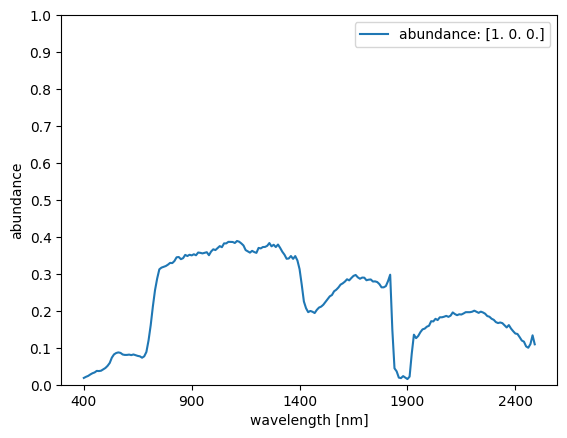

In [422]:
# Random spectrum generator!
rand_noise = torch.Tensor(np.random.random(3)) # 1d array
tot_abundance = 1
a = tot_abundance/np.random.randint(1, 100)
tot_abundance -= a
b = tot_abundance/np.random.randint(1, 100)
c = tot_abundance - b
abundance = [a, b, c]
adjusted = convolution.adjust(rand_noise, torch.Tensor(abundance))
produced_spectrum = convolution.decode(adjusted)
produced_spectrum = produced_spectrum.detach().numpy()
rand_noise = np.asarray(rand_noise)
# print(rand_noise)
# print(produced_spectrum)
joined = np.concatenate((rand_noise, abundance, produced_spectrum))

file.write(f'{joined[0]}')
for i in joined[1:]:
    file.write(f',{i}')
file.write(f'\n')
plt.plot(wavelengths, produced_spectrum, label=f'abundance: {np.asarray(abundance)}')
plt.ylim(0, 1)
plt.xticks([i for i in range(0, 250, 50)])
plt.yticks([i/10 for i in range(0, 11)])
plt.legend()
plt.xlabel(f'wavelength [nm]')
plt.ylabel(f'abundance')
plt.show()

In [423]:
file.close()